In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("../data/processed/online_retail_cleaned.csv", parse_dates=["InvoiceDate"])

cohort_df = df[["CustomerID", "Invoice", "InvoiceDate", "Revenue"]].copy()

print(cohort_df.shape)
cohort_df.head()

(805549, 4)


,CustomerID,Invoice,InvoiceDate,Revenue
0,13085,489434,2009-12-01 07:45:00,83.4
1,13085,489434,2009-12-01 07:45:00,81.0
2,13085,489434,2009-12-01 07:45:00,81.0
3,13085,489434,2009-12-01 07:45:00,100.8
4,13085,489434,2009-12-01 07:45:00,30.0


In [2]:
# Create month fields
cohort_df["InvoiceMonth"] = cohort_df["InvoiceDate"].dt.to_period("M")
cohort_df["CohortMonth"] = cohort_df.groupby("CustomerID")["InvoiceMonth"].transform("min")

# Calculate cohort index
invoice_year = cohort_df["InvoiceMonth"].dt.year
invoice_month = cohort_df["InvoiceMonth"].dt.month

cohort_year = cohort_df["CohortMonth"].dt.year
cohort_month = cohort_df["CohortMonth"].dt.month

cohort_df["CohortIndex"] = (invoice_year - cohort_year) * 12 + (invoice_month - cohort_month) + 1

cohort_df.head()

,CustomerID,Invoice,InvoiceDate,Revenue,InvoiceMonth,CohortMonth,CohortIndex
0,13085,489434,2009-12-01 07:45:00,83.4,2009-12,2009-12,1
1,13085,489434,2009-12-01 07:45:00,81.0,2009-12,2009-12,1
2,13085,489434,2009-12-01 07:45:00,81.0,2009-12,2009-12,1
3,13085,489434,2009-12-01 07:45:00,100.8,2009-12,2009-12,1
4,13085,489434,2009-12-01 07:45:00,30.0,2009-12,2009-12,1


In [3]:
cohort_counts = cohort_df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()

cohort_pivot = cohort_counts.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")

cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

retention_matrix.round(3)

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN
2010-05,1.0,0.157,0.169,0.173,0.177,0.256,0.213,0.126,0.059,0.083,...,0.126,0.138,0.165,0.154,0.047,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174,0.189,0.204,0.230,0.285,0.126,0.089,0.081,0.119,...,0.122,0.133,0.204,0.052,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.156,0.183,0.296,0.290,0.140,0.113,0.145,0.145,0.113,...,0.172,0.237,0.081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.204,0.296,0.321,0.173,0.117,0.099,0.123,0.136,0.130,...,0.198,0.068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


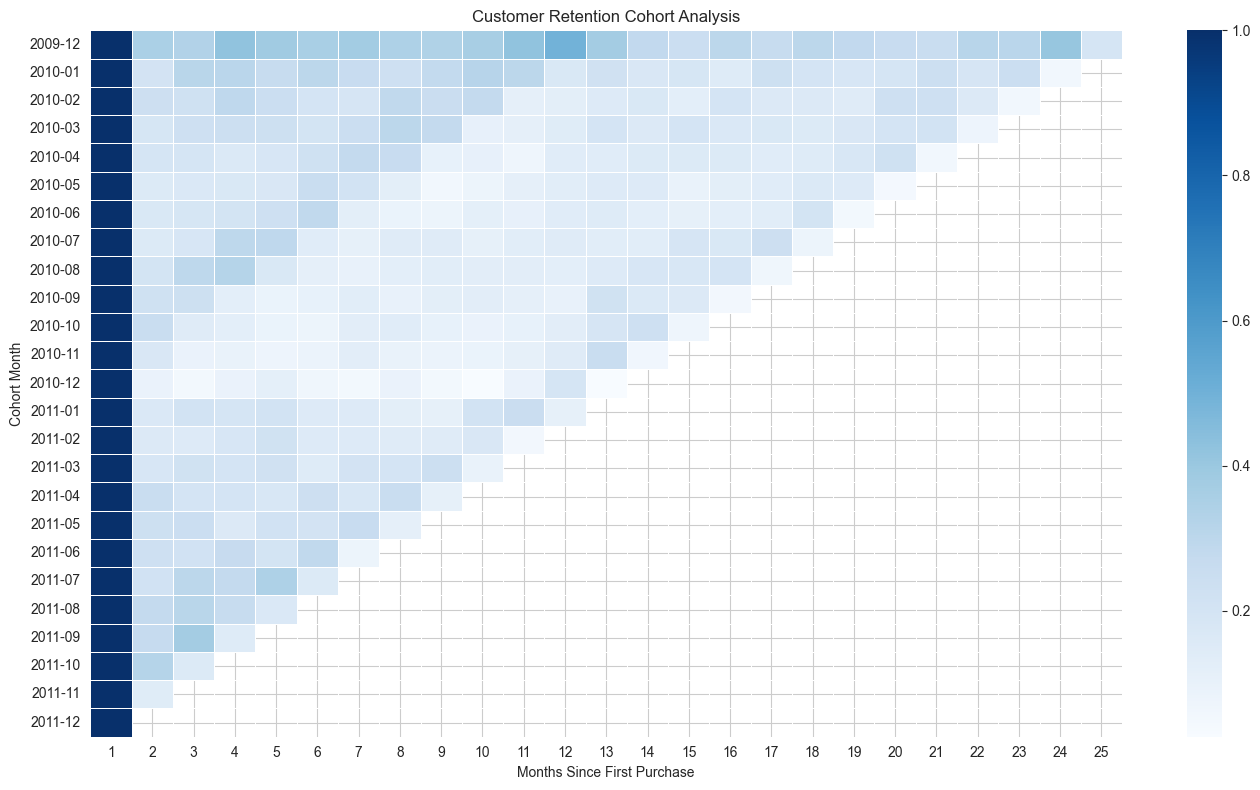

In [4]:
# Plot retention heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_matrix,
    annot=False,
    cmap="Blues",
    fmt=".0%",
    linewidths=0.5
)
plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

In [5]:
# Save a rounded version for reporting
retention_output = retention_matrix.round(3)
retention_output.to_csv("../data/output/cohort_retention_matrix.csv")
retention_output.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN


In [6]:
monthly_retention = retention_matrix.mean(axis=0).reset_index()
monthly_retention.columns = ["CohortIndex", "AverageRetention"]
monthly_retention

,CohortIndex,AverageRetention
0,1,1.000000
1,2,0.211656
2,3,0.219221
3,4,0.216158
4,5,0.205426
5,6,0.188438
6,7,0.178213
7,8,0.176571
8,9,0.156210
9,10,0.152556
